In [1]:
from calc_script import create_stats_df
from calc_script import create_plant_summary
from calc_script import create_a_summary_plot
from IPython.display import display

In [2]:
START_DATE = '2025-10-20'
END_DATE = '2026-04-20'
# START_DATE = '2025-04-20'
# END_DATE = '2025-07-20'
GET_ALL_DATES_FROM_MB51 = False

PRODUCTION_PLANT = '2101'

# 95% -> k = 1.96 (most common choice)
# 96% -> k = 2,05 (best choice)
# 99% -> k = 2.33
K_PARAMETER = 2.05

STD_MAD_TRESHOLD = 2.5


In [3]:
exchange_rates = {
    'EUR': 1.0,
    'PLN': 0.23,  # Przykład: 1 PLN = 0.23 EUR
    'CZK': 0.04   # Przykład: 1 CZK = 0.04 EUR
}

mb51_path = r"P:\Technisch\PLANY PRODUKCJI\PLANIŚCI\PP_TOOLS_TEMP_FILES\15_SAFETY_STOCKS_CALCULATIONS\input\L1K_Consumption.XLSX"
zsbe_path = r"P:\Technisch\PLANY PRODUKCJI\PLANIŚCI\PP_TOOLS_TEMP_FILES\15_SAFETY_STOCKS_CALCULATIONS\input\L1K_items_and_parameters.XLSX"
no_ss_items_path = r"P:\Technisch\PLANY PRODUKCJI\PLANIŚCI\PP_TOOLS_TEMP_FILES\15_SAFETY_STOCKS_CALCULATIONS\helper_files\no_ss_items.xlsx"

output_directory = r"P:\Technisch\PLANY PRODUKCJI\PLANIŚCI\PP_TOOLS_TEMP_FILES\15_SAFETY_STOCKS_CALCULATIONS\output"

In [4]:
stats_df = create_stats_df(mb51_path, zsbe_path, no_ss_items_path, PRODUCTION_PLANT, GET_ALL_DATES_FROM_MB51, START_DATE, END_DATE, K_PARAMETER, exchange_rates, STD_MAD_TRESHOLD)

Dates for calculations DatetimeIndex(['2025-10-20', '2025-10-21', '2025-10-22', '2025-10-23',
               '2025-10-24', '2025-10-27', '2025-10-28', '2025-10-29',
               '2025-10-30', '2025-10-31',
               ...
               '2026-04-07', '2026-04-08', '2026-04-09', '2026-04-10',
               '2026-04-13', '2026-04-14', '2026-04-15', '2026-04-16',
               '2026-04-17', '2026-04-20'],
              dtype='datetime64[ns]', length=131, freq='B')
   material material_description
0    793674  R48_ 065/118 K100RO
1    793672  R48_ 054/078 K100RO
2    793673  R48_ 054/098 K100RO
3    793677  R48_ 094/118 K100RO
4    793679  R48_ 114/118 K100RO
5    793614  R45_ 054/078 K100RO
6    793655  R45_ 054/098 K100RO
7    793656  R45_ 065/118 K100RO
8    793657  R45_ 074/118 K100RO
9    793658  R45_ 074/140 K100RO
10   793659  R45_ 094/118 K100RO
11   793660  R45_ 094/140 K100RO
12   793661  R45_ 114/118 K100RO
13   793662  R45_ 114/140 K100RO
14   793675  R48_ 074/118 K100RO

In [5]:
stats_df[['plant', 'material', 'material_description', 'lead_time',
                         'daily_avg_consumption', 'new_safety_stock', 'new_ss_range', 'new_safety_stock_value', 'reorder_point', 'ROP_value', 'safety_stock_in_SAP', 'ss_diff']].head(10)

,plant,material,material_description,lead_time,daily_avg_consumption,new_safety_stock,new_ss_range,new_safety_stock_value,reorder_point,ROP_value,safety_stock_in_SAP,ss_diff
0,2101,808965,R79_ 074/118 K200,2,12.2672,63,5.14,12591.95,88,17588.76,200,-137
1,3701,808965,R79_ 074/118 K200,7,11.1298,145,13.03,33627.12,223,51716.20,252,-107
2,2101,839134,R49_ 074/118 K200,2,10.3130,45,4.36,8882.06,66,13027.02,150,-105
3,2101,808966,R79_ 074/140 K200,2,8.9466,48,5.37,10391.29,66,14288.02,200,-152
4,2101,839135,R49_ 074/140 K200,2,6.5115,28,4.30,6018.63,42,9027.95,96,-68
5,3701,808966,R79_ 074/140 K200,3,4.4809,37,8.26,9298.62,51,12817.01,100,-63
6,1201,497669,R79T 114/118 K100L1,4,2.1832,14,6.41,2753.80,23,4524.10,50,-36
7,3701,808964,R79_ 074/098 K200,4,1.8473,15,8.12,3072.80,23,4711.63,35,-20
8,3701,2002538,R79C 074/118 K200,5,1.8321,22,12.01,5868.80,32,8536.44,19,3
9,1201,497661,R79T 078/098 K100L1,4,1.7023,13,7.64,2156.57,20,3317.80,40,-27


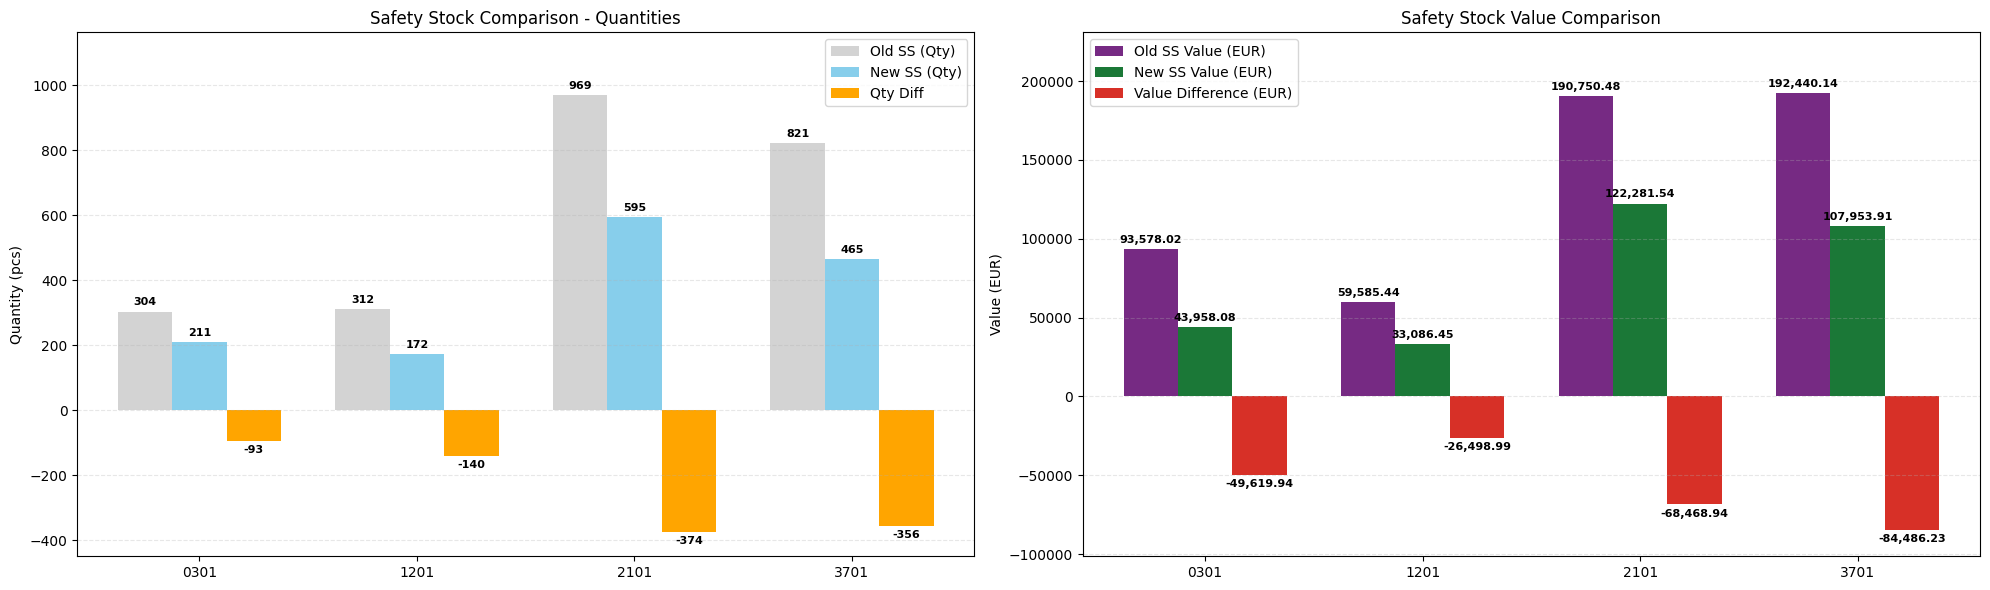

In [6]:
plant_summary = create_plant_summary(stats_df)
fig = create_a_summary_plot(plant_summary)
display(fig)

In [7]:
# stats_df = stats_df[['plant', 'material', 'material_description', 'daily_std_dev', 'lead_time',
#                      'daily_avg_consumption', 'new_safety_stock', 'new_ss_range', 'new_safety_stock_value',
#                      'reorder_point', 'ROP_value', 'safety_stock_in_SAP', 'ss_diff', 'volatility_method', 'daily_mad']]
stats_df.to_excel(f"{output_directory}\stats_df_past_6_months2.xlsx")